## Stage 1 — EDA

In [1]:
import sys
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

PROJECT_ROOT = Path.cwd() if Path.cwd().name != "notebooks" else Path.cwd().parent
CACHE_DIR = PROJECT_ROOT / "data" / "cache"
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from utils import compute_image_stats, plot_stat_histograms

In [2]:
dataset_clean = pd.read_pickle(CACHE_DIR / "dataset_clean.pkl")

print(f"Loaded {len(dataset_clean)} images from data/cache/dataset_clean.pkl")
print(dataset_clean["label"].value_counts().rename({1: "smile", 0: "non_smile"}))

Loaded 3970 images from data/cache/dataset_clean.pkl
label
smile        2151
non_smile    1819
Name: count, dtype: int64


In [3]:
stats = [
    compute_image_stats(cv2.imread(filepath))
    for filepath in tqdm(dataset_clean["filepath"], desc="Computing per-image stats")
]

stat_df = pd.DataFrame(stats)
overlap = [c for c in stat_df.columns if c in dataset_clean.columns]
dataset_stats = pd.concat(
    [dataset_clean.drop(columns=overlap).reset_index(drop=True), stat_df],
    axis=1,
)

print(dataset_stats[["brightness", "blur_val", "width", "height"]].describe())

Computing per-image stats: 100%|██████████| 3970/3970 [00:04<00:00, 972.13it/s] 

        brightness      blur_val        width       height
count  3970.000000   3970.000000  3970.000000  3970.000000
mean    111.546959    448.330223   184.307809   197.206549
std      31.733504    573.401227    35.508713    33.976466
min      14.482256      5.211907   110.000000   120.000000
25%      88.922311    153.258798   179.000000   192.000000
50%     110.541869    286.999289   180.000000   192.000000
75%     132.384997    537.288750   180.000000   192.000000
max     238.697522  11231.301680   972.000000   480.000000


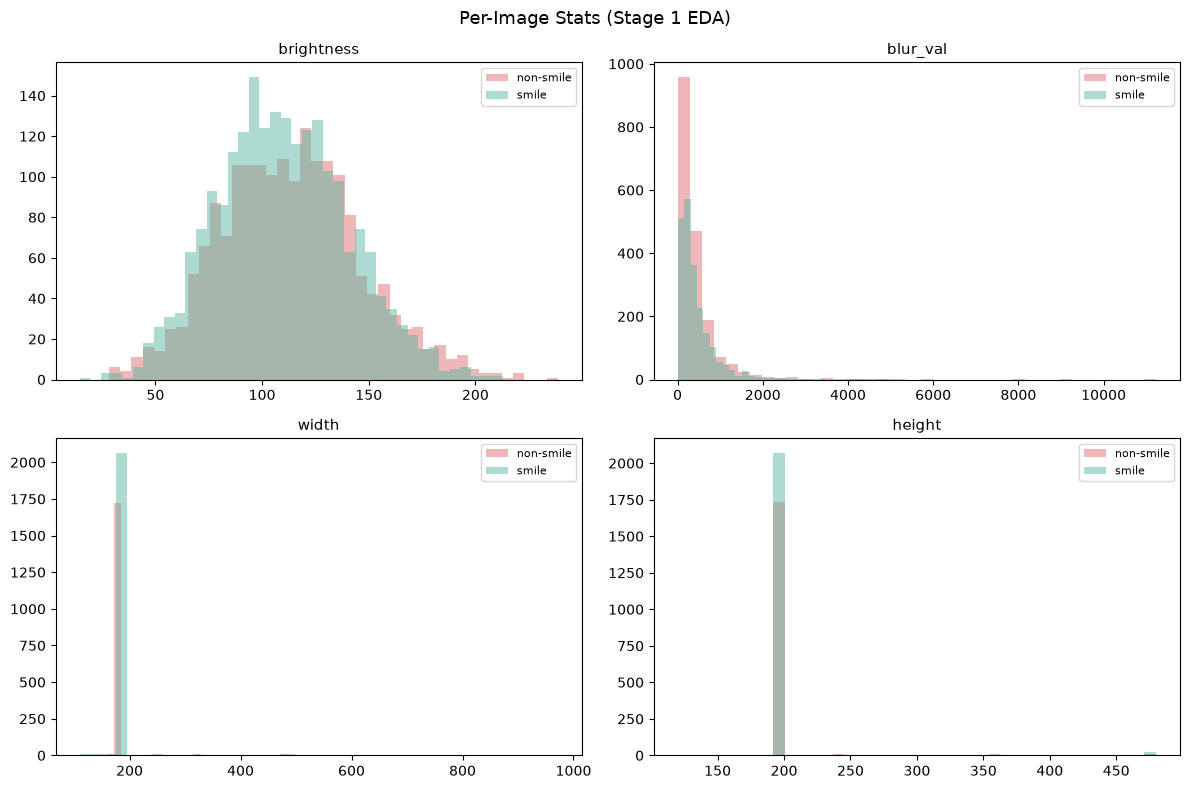

Saved to /mnt/hdd/projects/smile_detection/data/eda/stats_histograms.png


In [4]:
plot_stat_histograms(
    dataset_stats,
    save_path=str(PROJECT_ROOT / "data" / "eda" / "stats_histograms.png"),
)